## Background

The dataset contains measurements of several features that describe characteristics of cell nuclei present in digital images of breast tissue samples. These features include the **mean, standard error, "worst"** values of measurements such as *radius, texture, perimeter, area, smoothness, compactness, concavity, concave points, symmetry, and fractal dimension*. Each feature is represented by a numeric value, and each data point represents a sample from either a malignant (cancerous) or benign (non-cancerous) breast issue.

We want to be able to diagnose *malignant* cancer, and distinguish them from *benign* growths by employing ML techniques. The requirements for this task are:
- have at least 95% probability of detecting malignant cancer when it is present;
- have no more than 1 in 10 healthy cases (those with benign tumors) labelled as positive (malignant).

In [60]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [61]:
# Load the dataset
data = pd.read_csv('breast-cancer.csv')
data.head()

,label,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,malignant,15.494654,15.902542,103.008265,776.437239,0.104239,0.168660,0.170572,0.085668,0.205053,...,19.522957,22.427276,135.128520,1286.903131,0.142725,0.407483,0.445992,0.171662,0.353211,0.097731
1,malignant,16.229871,18.785613,105.176755,874.712003,0.091843,0.092548,0.081681,0.053670,0.180435,...,19.140235,24.905156,123.886045,1234.499997,0.129135,0.223918,0.248846,0.136735,0.284427,0.085758
2,malignant,16.345671,20.114076,107.083804,872.563251,0.099924,0.123799,0.128788,0.078310,0.189756,...,19.144816,25.601433,125.113036,1202.749973,0.135017,0.314402,0.332505,0.161497,0.313038,0.084340
3,malignant,13.001009,19.876997,85.889775,541.281012,0.113423,0.173069,0.146214,0.069574,0.212078,...,15.565911,26.145119,102.958265,737.655082,0.161390,0.485912,0.430007,0.167254,0.432297,0.117705
4,malignant,16.416060,17.397533,107.857386,891.516818,0.097321,0.111530,0.125971,0.068575,0.179562,...,18.620376,22.306233,124.002529,1139.490971,0.133950,0.230996,0.316620,0.131715,0.269591,0.080497


In [62]:
# Size checking
print ("Size: ", data.shape)
# Columns
print ("Columns: ", data.columns)

Size:  (300, 31)
Columns:  Index(['label', 'mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension'],
      dtype='object')


In [63]:
labels = data['label'].unique()
print ("Labels: ", labels)

Labels:  ['malignant' 'benign']


In [64]:
# Separate three groups into separate df
mean_group = data.iloc[:,1:10]
se_group = data.iloc[:,11:20]
worst_group = data.iloc[:,21:]

Histograms for each feature of the three groups:

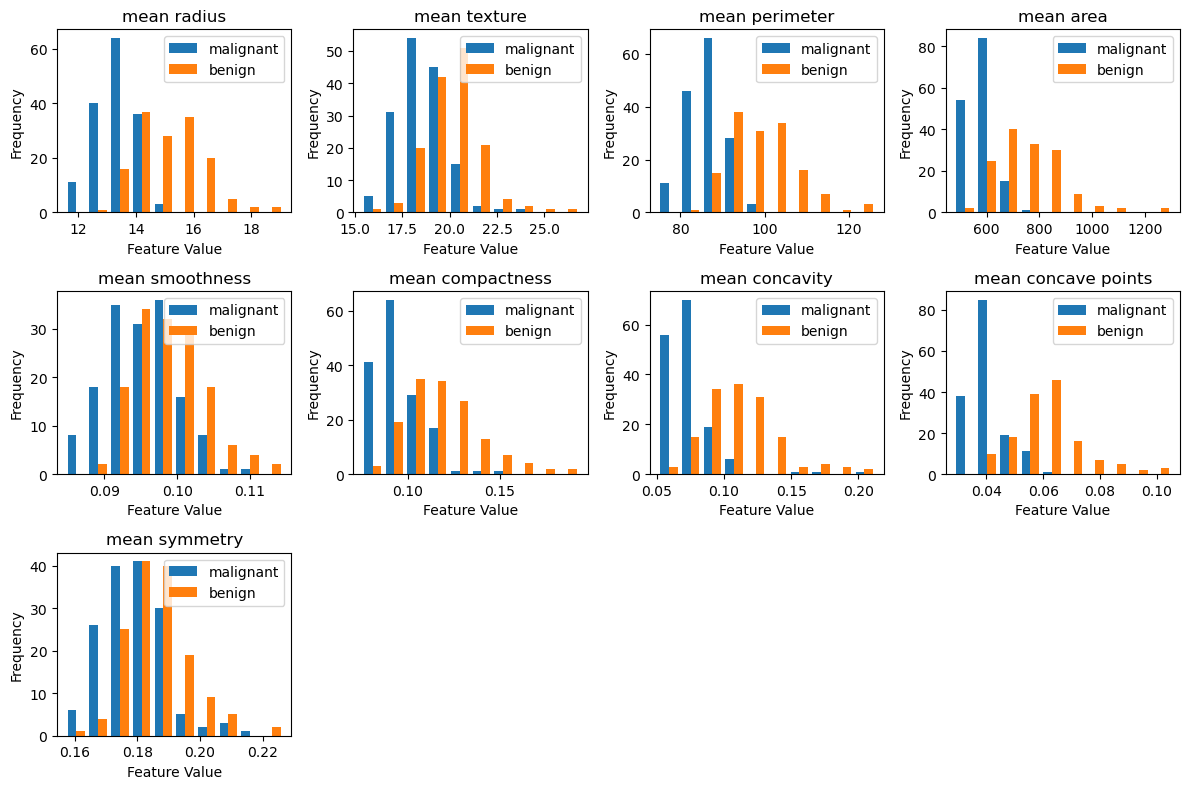

In [65]:
# Mean group
fig = plt.figure(figsize=(12,8))
for i, feature in enumerate(mean_group.columns):
    plt.subplot(3, 4, i+1)
    plt.hist([mean_group[feature][data['label'] == 'benign'], mean_group[feature]
             [data['label'] == 'malignant']], label=labels)
    plt.xlabel("Feature Value")
    plt.ylabel("Frequency")
    plt.legend()
    plt.title(feature)
plt.tight_layout()
plt.show()

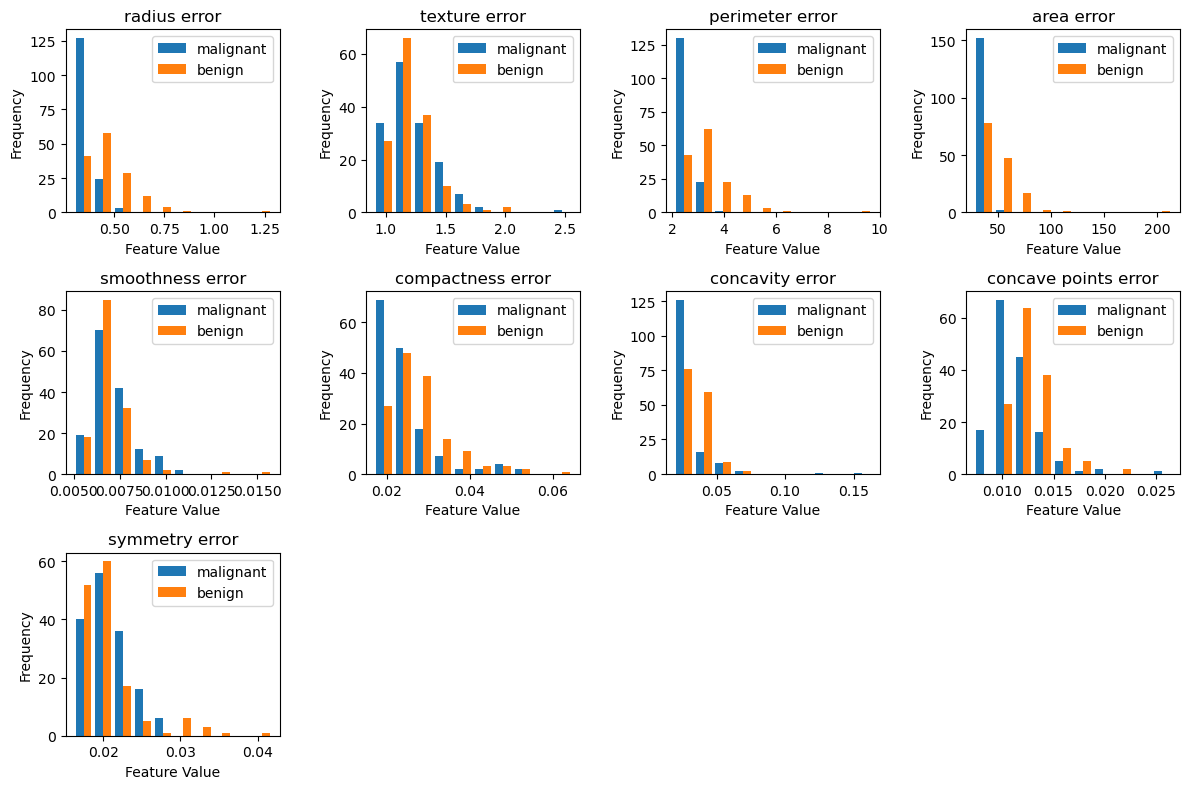

In [66]:
# Standard error group
fig = plt.figure(figsize=(12,8))
for i, feature in enumerate(se_group.columns):
    plt.subplot(3, 4, i+1)
    plt.hist([se_group[feature][data['label'] == 'benign'], se_group[feature]
             [data['label'] == 'malignant']], label=labels)
    plt.xlabel("Feature Value")
    plt.ylabel("Frequency")
    plt.legend()
    plt.title(feature)
plt.tight_layout()
plt.show()

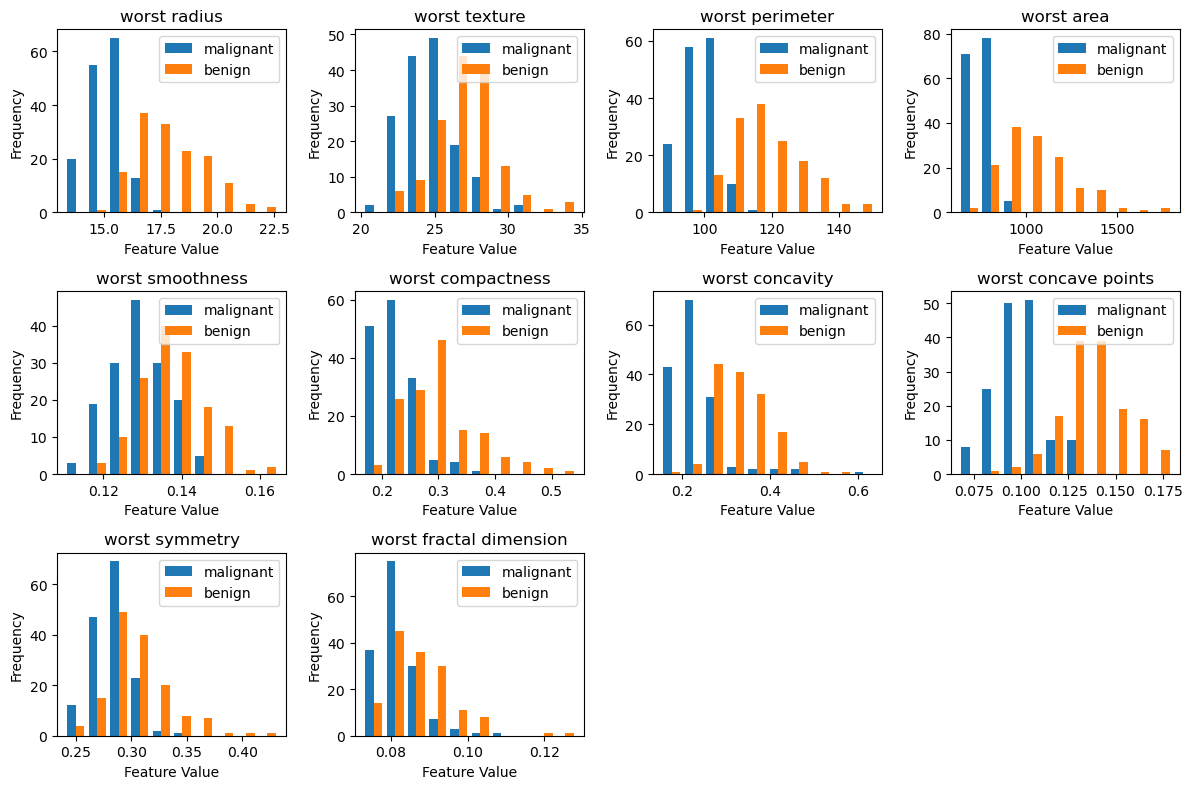

In [67]:
# Worst group
fig = plt.figure(figsize=(12,8))
for i, feature in enumerate(worst_group.columns):
    plt.subplot(3, 4, i+1)
    plt.hist([worst_group[feature][data['label'] == 'benign'], worst_group[feature]
             [data['label'] == 'malignant']], label=labels)
    plt.xlabel("Feature Value")
    plt.ylabel("Frequency")
    plt.legend()
    plt.title(feature)
plt.tight_layout()
plt.show()

In [68]:
# Convert labels to binary (benign = 0, malignant = 1)
data['label'] = data['label'].map({'benign': 0, 'malignant': 1}).apply(pd.to_numeric, errors='coerce')
data['label'].unique()

array([1, 0])

In [69]:
from sklearn.model_selection import train_test_split
# Split the data into training, validation, and test sets
bigtrain_set, test_set = train_test_split(data, test_size=0.2, random_state=42, stratify=data.iloc[:,0])
train_set, val_set = train_test_split(bigtrain_set, test_size=0.25, random_state=42, stratify=bigtrain_set.iloc[:,0])

X_train = train_set.iloc[:,1:]
y_train = train_set.iloc[:,0]
X_val = val_set.iloc[:,1:]
y_val = val_set.iloc[:,0]
X_test = test_set.iloc[:,1:]
y_test = test_set.iloc[:,0]

### Baseline measurements

We consider 3 simple baseline cases:
1. predict all samples to be negative (class 1 - benign)
2. predict all samples to be positive (class 2 - malignant)
3. make a random prediction for each sample with equal probability for each class

In [70]:
# arr to hold the predicted labels
y_test_arr = np.array(y_test)

# Case 1: All samples are benign
baseline1_preds = np.zeros(len(y_test_arr))

# Case 2: All samples are malignant
baseline2_preds = np.ones(len(y_test_arr))

# Case 3: Randomly assign benign or malignant
np.random.seed(42)
baseline3_preds = np.random.choice([0,1], size=len(y_test_arr))

print(baseline1_preds)
print(baseline2_preds)
print(baseline3_preds)

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
[0 1 0 0 0 1 0 0 0 1 0 0 0 0 1 0 1 1 1 0 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 0 1
 0 0 0 0 0 1 1 1 1 1 0 1 1 0 1 0 1 0 1 1 0 0 0]


In [71]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, f1_score

def calculate_metrics(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    return accuracy, precision, recall, roc_auc, f1

baseline1_metrics = calculate_metrics(y_test_arr, baseline1_preds)
baseline2_metrics = calculate_metrics(y_test_arr, baseline2_preds)
baseline3_metrics = calculate_metrics(y_test_arr, baseline3_preds)

print("Baseline 1 Metrics: ", baseline1_metrics)
print("Baseline 2 Metrics: ", baseline2_metrics)
print("Baseline 3 Metrics: ", baseline3_metrics)

Baseline 1 Metrics:  (0.5166666666666667, 0.0, 0.0, 0.5, 0.0)
Baseline 2 Metrics:  (0.48333333333333334, 0.48333333333333334, 1.0, 0.5, 0.651685393258427)
Baseline 3 Metrics:  (0.5, 0.4838709677419355, 0.5172413793103449, 0.5005561735261401, 0.5)


In [72]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Pre-processing pipeline
preproc_pl = Pipeline([('imputer', SimpleImputer(strategy='mean')), ('scaler', StandardScaler())])

In [73]:
from sklearn.linear_model import SGDClassifier

# Create pipeline and fit the training data
sgd_pl = Pipeline([('preproc', preproc_pl), ('sgd', SGDClassifier(random_state=42))])
sgd_pl.fit(X_train, y_train)

# Evaluate on the validation data
sgd_y_val_pred = sgd_pl.predict(X_val)

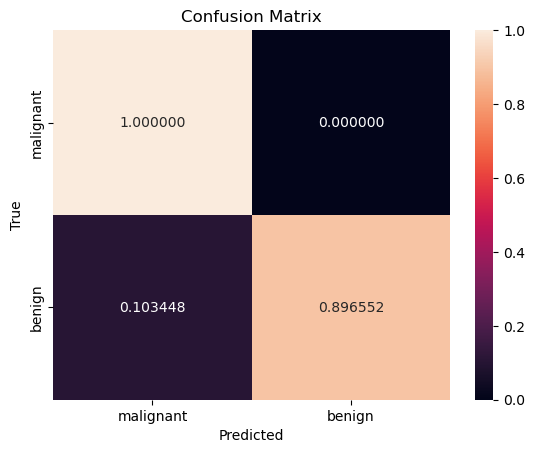

In [74]:
from sklearn.metrics import confusion_matrix

cmat = confusion_matrix(y_val, sgd_y_val_pred, normalize='true')
sns.heatmap(cmat, annot=True, fmt='f', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [75]:
print("Probability that a sample from a person with a malignant tumor given that they do not have cancer: ", cmat[1,0]) # false negative rate
print ("The baseline model statisfies the client's criterion.") if cmat[1,0] <=0.1 else print ("The baseline model does not satisfy the client's criterion.")

Probability that a sample from a person with a malignant tumor given that they do not have cancer:  0.10344827586206896
The baseline model does not satisfy the client's criterion.


### K-Nearest Neighbor Classifier

In [76]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

knn_pl = Pipeline([('preproc', preproc_pl), ('knn', KNeighborsClassifier())])
knn_params = [{'knn__n_neighbors': list(range(1,11)),
               'knn__weights': ['uniform', 'distance'],
               'knn__metric': ['euclidean', 'minkowski'],
               'knn__algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
               'knn__p': [1, 2]}]
knn_model = GridSearchCV(knn_pl, knn_params, cv=5, scoring='roc_auc', return_train_score=True)
knn_model.fit(X_train, y_train)

knn_best_params = knn_model.best_params_

### Decision Tree Classifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_pl = Pipeline([('preproc', preproc_pl), ('dt', DecisionTreeClassifier(random_state=42))])
dt_params = [{'dt__criterion': ['gini', 'entropy'],
              'dt__max_depth': list(range(1,21,2)),
              'dt__min_samples_split': list(range(1,21,2)),
              'dt__min_samples_leaf': list(range(1,21,2)),
              'dt__max_features': ['auto', 'sqrt', 'log2']}]
dt_model = GridSearchCV(dt_pl, dt_params, cv=5, scoring='roc_auc', return_train_score=True)
dt_model.fit(X_train, y_train)
dt_best_params = dt_model.best_params_

### C-Support Vector Classification (SVC)

In [ ]:
from sklearn.svm import SVC

svc_pl = Pipeline([('preproc', preproc_pl), ('svc', SVC(random_state=42))])
svc_params = [{'svc__C': [0.01, 0.1, 1, 10, 100],
               'svc__kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
               'svc__gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1]}]
svc_model = GridSearchCV(svc_pl, svc_params, cv=5, scoring='roc_auc', return_train_score=True)
svc_model.fit(X_train, y_train)
svc_best_params = svc_model.best_params_

### SGD Classifier

In [ ]:
sgd_params = [{'sgd__loss': ['hinge', 'log', 'squared_hinge', 'perceptron'],
               'sgd__penalty': ['l2', 'l1'],
               'sgd__alpha': [0.0001, 0.001, 0.01, 0.1, 1],
               'sgd__learning_rate': ['constant', 'optimal', 'invscaling', 'adaptive'],
               'sgd__eta0': [0.01, 0.1, 1]}]
sgd_model = GridSearchCV(sgd_pl, sgd_params, cv=5, scoring='roc_auc', return_train_score=True)
sgd_model.fit(X_train, y_train)
sgd_best_params = sgd_model.best_params_

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_stochastic_gradient.py:744: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_stochastic_gradient.py:744: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_stochastic_gradient.py:744: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_stochastic_gradient.py:744: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/line

In [ ]:
# Best parameters for each model
print("Best parameters for KNN: ", knn_best_params)
print("Best parameters for Decision Tree: ", dt_best_params)
print("Best parameters for SVC: ", svc_best_params)
print("Best parameters for SGD: ", sgd_best_params)

Best parameters for KNN:  {'knn__algorithm': 'auto', 'knn__metric': 'minkowski', 'knn__n_neighbors': 8, 'knn__p': 1, 'knn__weights': 'distance'}
Best parameters for Decision Tree:  {'dt__criterion': 'gini', 'dt__max_depth': 3, 'dt__max_features': 'sqrt', 'dt__min_samples_leaf': 11, 'dt__min_samples_split': 3}
Best parameters for SVC:  {'svc__C': 1, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}
Best parameters for SGD:  {'sgd__alpha': 1, 'sgd__eta0': 0.01, 'sgd__learning_rate': 'optimal', 'sgd__loss': 'squared_hinge', 'sgd__penalty': 'l2'}


In [ ]:
# Best scores for each model
best_scores = {
    'KNN': knn_model.best_score_,
    'Decision Tree': dt_model.best_score_,
    'SVC': svc_model.best_score_,
    'SGD': sgd_model.best_score_
}

for i in range(len(best_scores)):
    print(f"Best score for {list(best_scores.keys())[i]}: {list(best_scores.values())[i]}")

top3_models = sorted(best_scores.items(), key=lambda x: x[1], reverse=True)[:3]
print("Top 3 models: ", top3_models)

Best score for KNN: 0.9895023506478615
Best score for Decision Tree: 0.9545808966861598
Best score for SVC: 0.9907369185490961
Best score for SGD: 0.9870332148453924
Top 3 models:  [('SVC', 0.9907369185490961), ('KNN', 0.9895023506478615), ('SGD', 0.9870332148453924)]


In [ ]:
# Assign best params for each model to a dict
best_model1_params = {key.replace('svc__',''): value for key, value in svc_best_params.items()}
best_model2_params = {key.replace('knn__',''): value for key, value in knn_best_params.items()}
best_model3_params = {key.replace('sgd__',''): value for key, value in sgd_best_params.items()}

best_model1_pl = Pipeline([('preproc', preproc_pl), ('svc', SVC(**best_model1_params))])
best_model2_pl = Pipeline([('preproc', preproc_pl), ('knn', KNeighborsClassifier(**best_model2_params))])
best_model3_pl = Pipeline([('preproc', preproc_pl), ('sgd', SGDClassifier(**best_model3_params))])
best_model1_pl.fit(X_train, y_train)
best_model2_pl.fit(X_train, y_train)
best_model3_pl.fit(X_train, y_train)

# Evaluate on the validation data
best_model1_y_val_pred = best_model1_pl.predict(X_val)
best_model2_y_val_pred = best_model2_pl.predict(X_val)
best_model3_y_val_pred = best_model3_pl.predict(X_val)

# Metrics for each model
best_model1_metrics = calculate_metrics(y_val, best_model1_y_val_pred)
best_model2_metrics = calculate_metrics(y_val, best_model2_y_val_pred)
best_model3_metrics = calculate_metrics(y_val, best_model3_y_val_pred)

print("Best Model 1 Metrics: ", best_model1_metrics)
print("Best Model 2 Metrics: ", best_model2_metrics)
print("Best Model 3 Metrics: ", best_model3_metrics)

Best Model 1 Metrics:  (0.9333333333333333, 1.0, 0.8620689655172413, 0.9310344827586207, 0.9259259259259259)
Best Model 2 Metrics:  (0.9666666666666667, 1.0, 0.9310344827586207, 0.9655172413793103, 0.9642857142857143)
Best Model 3 Metrics:  (0.95, 1.0, 0.896551724137931, 0.9482758620689655, 0.9454545454545454)


In [ ]:
X_train_final = X_train.copy()
y_train_final = y_train.copy()

final_model = best_model2_pl
final_model.fit(X_train_final, y_train_final)

# Evaluate on the test data
final_y_test_pred = final_model.predict(X_test)
final_roc_auc = roc_auc_score(y_test, final_y_test_pred)
print("Final Model ROC AUC: ", final_roc_auc)

Final Model ROC AUC:  0.9655172413793103


In [ ]:
def calculate_t_score(x1, x2):
    t_score = (x2.mean() - x1.mean())/(0.5*(x2.std() + x1.std()))
    return t_score

# Split the training data into two datasets corresponding to the two classes
benign = data[data.iloc[:, 0] == 0]  # Class 0
malignant = data[data.iloc[:, 0] == 1]  # Class 1

# Calculate the T score for the feature
t_scores = {}
for feature in data.columns[1:]:
    benign_feature = benign[feature]
    malignant_feature = malignant[feature]
    t_score = calculate_t_score(benign_feature, malignant_feature)
    t_scores[feature] = t_score
    print(f'T-score for {feature}: {t_score}')

# Sort the features by their absolute T-score in descending order
sorted_features = sorted(t_scores.items(), key=lambda item: abs(item[1]), reverse=True)

# Get the best 4 features
best_four_features = [feature for feature, score in sorted_features[:4]]
print(f'\nBest four features : {best_four_features}')

T-score for mean radius: 2.003183622757792
T-score for mean texture: 1.0858009018741248
T-score for mean perimeter: 2.082304480877681
T-score for mean area: 1.9225287384194782
T-score for mean smoothness: 0.7424559355220665
T-score for mean compactness: 1.4255721566309414
T-score for mean concavity: 1.6087855066521732
T-score for mean concave points: 2.229435693128836
T-score for mean symmetry: 0.6415664539538811
T-score for mean fractal dimension: 0.01132731604299003
T-score for radius error: 1.2764298957289346
T-score for texture error: -0.09237150211402503
T-score for perimeter error: 1.298604501064557
T-score for area error: 1.4055110522365555
T-score for smoothness error: -0.18916082599996706
T-score for compactness error: 0.5073385648671896
T-score for concavity error: 0.33609474884882184
T-score for concave points error: 0.6678662933879556
T-score for symmetry error: -0.12308665422831884
T-score for fractal dimension error: 0.06228049309744642
T-score for worst radius: 2.4108393

In [ ]:
from sklearn.inspection import DecisionBoundaryDisplay

# Assign the name of the best feature obtained in step18 to the variable below. (string)
feature_one = best_four_features[0]

# Assign the name of the second best feature obtained in step18 to the variable below. (string)
feature_two = best_four_features[1]

# Assign the training dataset that you would want to use for this step to the variable below
data2d = X_train_final[[feature_one, feature_two]].copy()
print(f'\nData2D : {data2d}')

final_model.fit(data2d, y_train_final)



Data2D :      worst concave points  worst perimeter
6                0.142871       123.466254
81               0.134551       104.054337
166              0.088222        93.757583
233              0.129290       126.480988
223              0.124011       113.073947
..                    ...              ...
228              0.113006        99.512055
87               0.146717       125.921595
28               0.146876       123.217490
36               0.125918       110.767535
199              0.138884       110.583689

[180 rows x 2 columns]


Pipeline(steps=[('preproc',
                 Pipeline(steps=[('imputer', SimpleImputer()),
                                 ('scaler', StandardScaler())])),
                ('knn',
                 KNeighborsClassifier(n_neighbors=8, p=1, weights='distance'))])

(86.81018449584168, 150.6532322953328)

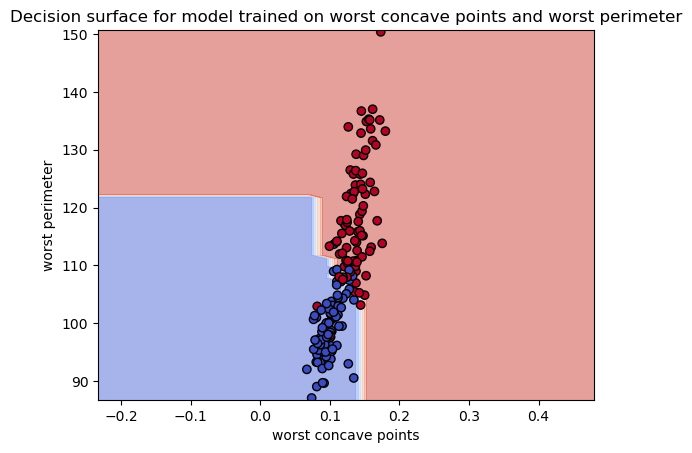

In [ ]:
disp = DecisionBoundaryDisplay.from_estimator(
    final_model,
    data2d,
    response_method="predict",
    cmap=plt.cm.coolwarm,
    alpha=0.5,
    grid_resolution=100
)

# Plotting the data points (for scatter plot)
disp.ax_.scatter(X_train[feature_one], X_train[feature_two],
                        c=y_train, edgecolor="k", cmap=plt.cm.coolwarm)
plt.title(f"Decision surface for model trained on {feature_one} and {feature_two}")
plt.xlim(X_train[feature_one].min() - 0.3, X_train[feature_one].max() + 0.3)
plt.ylim(X_train[feature_two].min() - 0.3, X_train[feature_two].max() + 0.3)
